# Notebook 01 — Data Loading

Load the jsons, inspect schema, count the rows and peak, cast a date column.

#### 1. Start Spark session

Connect to (or create) a Spark session and confirm whether we're running locally or on YARN.

In [2]:

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("PRAC").getOrCreate()
print("Master:", spark.sparkContext.master)

Master: yarn


26/04/20 11:43:30 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


#### 2. Load JSON and inspect schema

Read all JSON files from HDFS into a df. check out the schema.

In [22]:
df = spark.read.json("/data/ProjectDatasetFacebookAU/")

df.printSchema()

root
 |-- ad_creation_time: string (nullable = true)
 |-- ad_creative_bodies: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_creative_body: string (nullable = true)
 |-- ad_creative_link_caption: string (nullable = true)
 |-- ad_creative_link_captions: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_creative_link_description: string (nullable = true)
 |-- ad_creative_link_descriptions: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_creative_link_title: string (nullable = true)
 |-- ad_creative_link_titles: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_delivery_start_time: string (nullable = true)
 |-- ad_delivery_stop_time: string (nullable = true)
 |-- ad_snapshot_url: string (nullable = true)
 |-- bylines: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- delivery_by_region: array (nullable = true)
 |    |-- element: struct (containsN

#### 3. Row count and preview

Get a rough sense of data volume and check a sample of records.

In [4]:
df.show(5, truncate=80)
print("Row count:", df.count())

26/04/20 11:45:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------------+------------------+--------------------------------------------------------------------------------+------------------------+-------------------------+--------------------------------------------------------------------------------+-----------------------------+------------------------------+-----------------------+----------------------+---------------------+--------------------------------------------------------------------------------+-------+--------+------------------+--------------------------------------------------------------------------------+-----------------------+-----------------+----------------+------------+---------+----------------+-----------------+-------------------+-------------------+----------+
|ad_creation_time|ad_creative_bodies|                                                                ad_creative_body|ad_creative_link_caption|ad_creative_link_captions|                                                    ad_creative_link_description|ad_

Row count: 39584139


#### 4. Cast ad_creation_time to date

ad_creation_time is loaded as a string. Add a typed ad_creation_datetime column alongside the original. 

turns out there's a more than one date format - lets do a check.

In [14]:
from pyspark.sql.functions import length, count, first

df.groupBy(length("ad_creation_time").alias("len")) \
  .agg(count("*").alias("count"), first("ad_creation_time").alias("example")) \
  .orderBy("len") \
  .show(truncate=False)

+---+--------+------------------------+
|len|count   |example                 |
+---+--------+------------------------+
|10 |39505667|2021-10-31              |
|24 |78472   |2020-08-20T01:23:22+0000|
+---+--------+------------------------+



given most of the data has the yyyy-mm-dd format, it's probably safe enough to just truncate everything to 10 characters to clean up the 80,000 odd ones

In [23]:
from pyspark.sql.functions import to_date, substring

df = df.withColumn("ad_creation_date", to_date(substring("ad_creation_time", 1, 10), "yyyy-MM-dd"))

df.select("ad_creation_time", "ad_creation_date").show(5)

+----------------+----------------+
|ad_creation_time|ad_creation_date|
+----------------+----------------+
|      2021-11-21|      2021-11-21|
|      2021-12-02|      2021-12-02|
|      2021-12-02|      2021-12-02|
|      2021-12-02|      2021-12-02|
|      2021-12-02|      2021-12-02|
+----------------+----------------+
only showing top 5 rows



## 5. schema cleanup

there seems to be some duplicate/adjacent schema entries, for example 

 |-- ad_creative_bodies: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ad_creative_body: string (nullable = true)

what i'm going to try and do is groupBy month, then count the nulls in each column, then return the columns, months and counts to pandas/seaborn for plotting. this should allow us to visualise the schema changes over time.

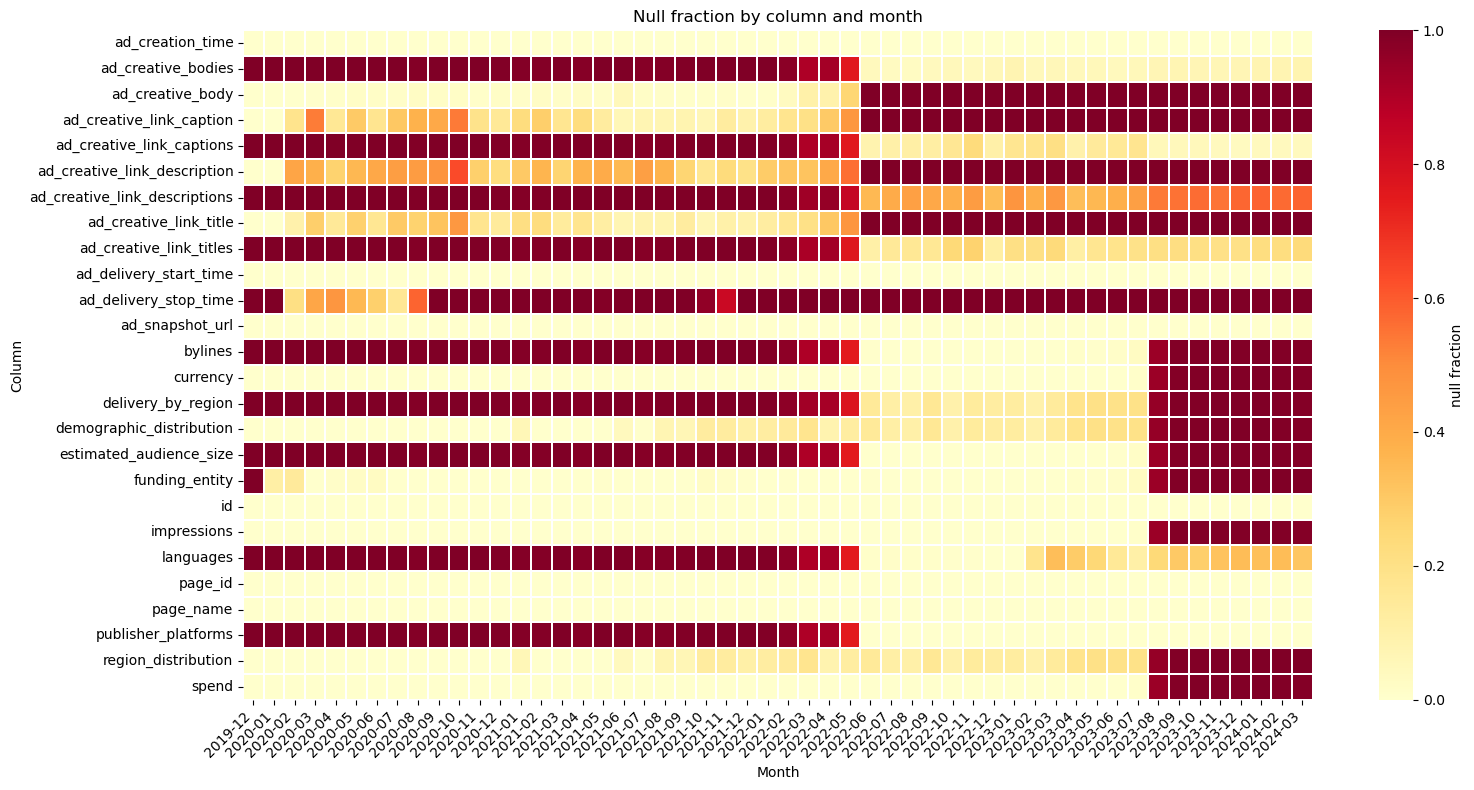

In [24]:
from pyspark.sql.functions import col, sum as spark_sum, count, date_trunc
import seaborn as sns
import matplotlib.pyplot as plt

cols = [c for c in df.columns if c != "ad_creation_date"]
agg_exprs = [count("*").alias("_total")] + [spark_sum(col(c).isNull().cast("int")).alias(c) for c in cols]

null_by_month = df \
    .withColumn("month", date_trunc("month", "ad_creation_date")) \
    .groupBy("month") \
    .agg(*agg_exprs) \
    .orderBy("month")

pdf = null_by_month.toPandas()

months = pdf["month"]
totals = pdf["_total"]
frac = pdf[cols].divide(totals, axis=0)
frac.index = months
plt.figure(figsize=(16, 8))
frac.index = frac.index.strftime("%Y-%m")
sns.heatmap(
    frac.T,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "null fraction"}
)
plt.title("Null fraction by column and month")
plt.xlabel("Month")
plt.ylabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

some things to note;

in 2022 some columns where changed from arrays to singular. choices are a) keep the first element from the array, drop the rest and keep everything as singular, or b) turn the singulars into single element arrays. I've gone with b) as it doesnt blow away the data.

sql is a bit simpler in this case - just explicitly define the schema.

In [25]:
df.createOrReplaceTempView("ads")

df = spark.sql("""
    SELECT
        id,
        page_id,
        page_name,
        funding_entity,
        ad_creation_time,
        ad_creation_date,
        ad_delivery_start_time,
        ad_delivery_stop_time,
        coalesce(ad_creative_bodies,       array(ad_creative_body))        AS creative_bodies,
        coalesce(ad_creative_link_captions,array(ad_creative_link_caption)) AS creative_link_captions,
        coalesce(ad_creative_link_descriptions, array(ad_creative_link_description)) AS creative_link_descs,
        coalesce(ad_creative_link_titles,  array(ad_creative_link_title))  AS creative_link_titles,
        impressions,
        spend,
        currency,
        languages,
        publisher_platforms,
        demographic_distribution,
        delivery_by_region,
        region_distribution,
        estimated_audience_size,
        ad_snapshot_url,
        bylines
    FROM ads
""")

and lets regroup and replot.

do i have to do this again from scratch? it only takes a minute at this point, so i've just cut and paste for now

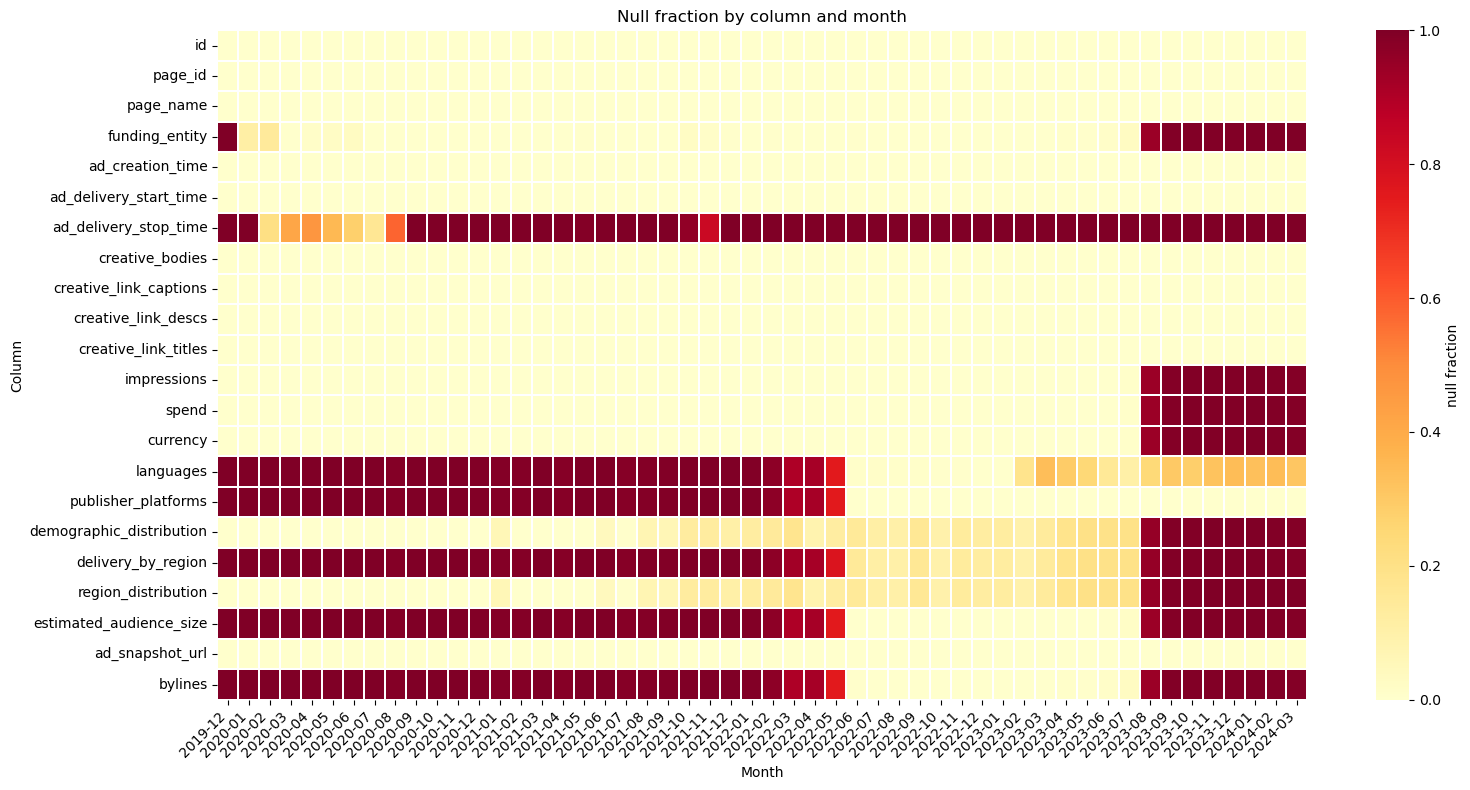

In [26]:
from pyspark.sql.functions import col, sum as spark_sum, count, date_trunc
import seaborn as sns
import matplotlib.pyplot as plt

cols = [c for c in df.columns if c != "ad_creation_date"]
agg_exprs = [count("*").alias("_total")] + [spark_sum(col(c).isNull().cast("int")).alias(c) for c in cols]

null_by_month = df \
    .withColumn("month", date_trunc("month", "ad_creation_date")) \
    .groupBy("month") \
    .agg(*agg_exprs) \
    .orderBy("month")

pdf = null_by_month.toPandas()

months = pdf["month"]
totals = pdf["_total"]
frac = pdf[cols].divide(totals, axis=0)
frac.index = months
plt.figure(figsize=(16, 8))
frac.index = frac.index.strftime("%Y-%m")
sns.heatmap(
    frac.T,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "null fraction"}
)
plt.title("Null fraction by column and month")
plt.xlabel("Month")
plt.ylabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()